## libraries

In [36]:

library(ggplot2)
library(dplyr)
library(optparse)
library(treemapify)
library(patchwork)

## Functions import from external files


In [37]:
source("generate_fzecComparison.R")
source("generate_histogram.R")
source("generate_treemap.R")

## Read dat

In [38]:
TAIWAN <- read.csv("/Users/B328695/Desktop/Biotools/BLCA/blcaPlotScripts/test_data/blcm_analysis_TAIWAN.csv")
TAIWAN_phylotypes <- read.csv("/Users/B328695/Desktop/Biotools/BLCA/blcaPlotScripts/test_data/TAIWAN_phylotypes_results.txt", header = F, sep = "\t")
colnames(TAIWAN_phylotypes) <- c("Sample_Name", "phylotype")

TAIWAN_meat_ids <- read.csv("/Users/B328695/Desktop/TAIWAN/TAIWAN_meat_ids_passedQC.csv", header = F)


### combining and filtering

In [39]:
TAIWAN_combined <- TAIWAN %>% 
  select(Sample_Name, MLST, Meat_pred) %>%
  left_join(TAIWAN_phylotypes, by = "Sample_Name")


TAIWAN_combined_MEAT <- TAIWAN_combined[TAIWAN_combined$Sample_Name %in% TAIWAN_meat_ids$V1,] 
TAIWAN_combined_HUMAN <- TAIWAN_combined[!(TAIWAN_combined$Sample_Name %in% TAIWAN_meat_ids$V1),]
#DTU_combined <- DTU_combined[!(DTU_combined$Sample_Name %in% c("ESBL20160100", "AMA005045", "CPO20190154", "ESBL20140215", "ESBL20150151","ESBL20170224","ESBL20180299","ESBL20180330","ESBL20200449","ESBL20250462")),] 
  


## Generating histograms

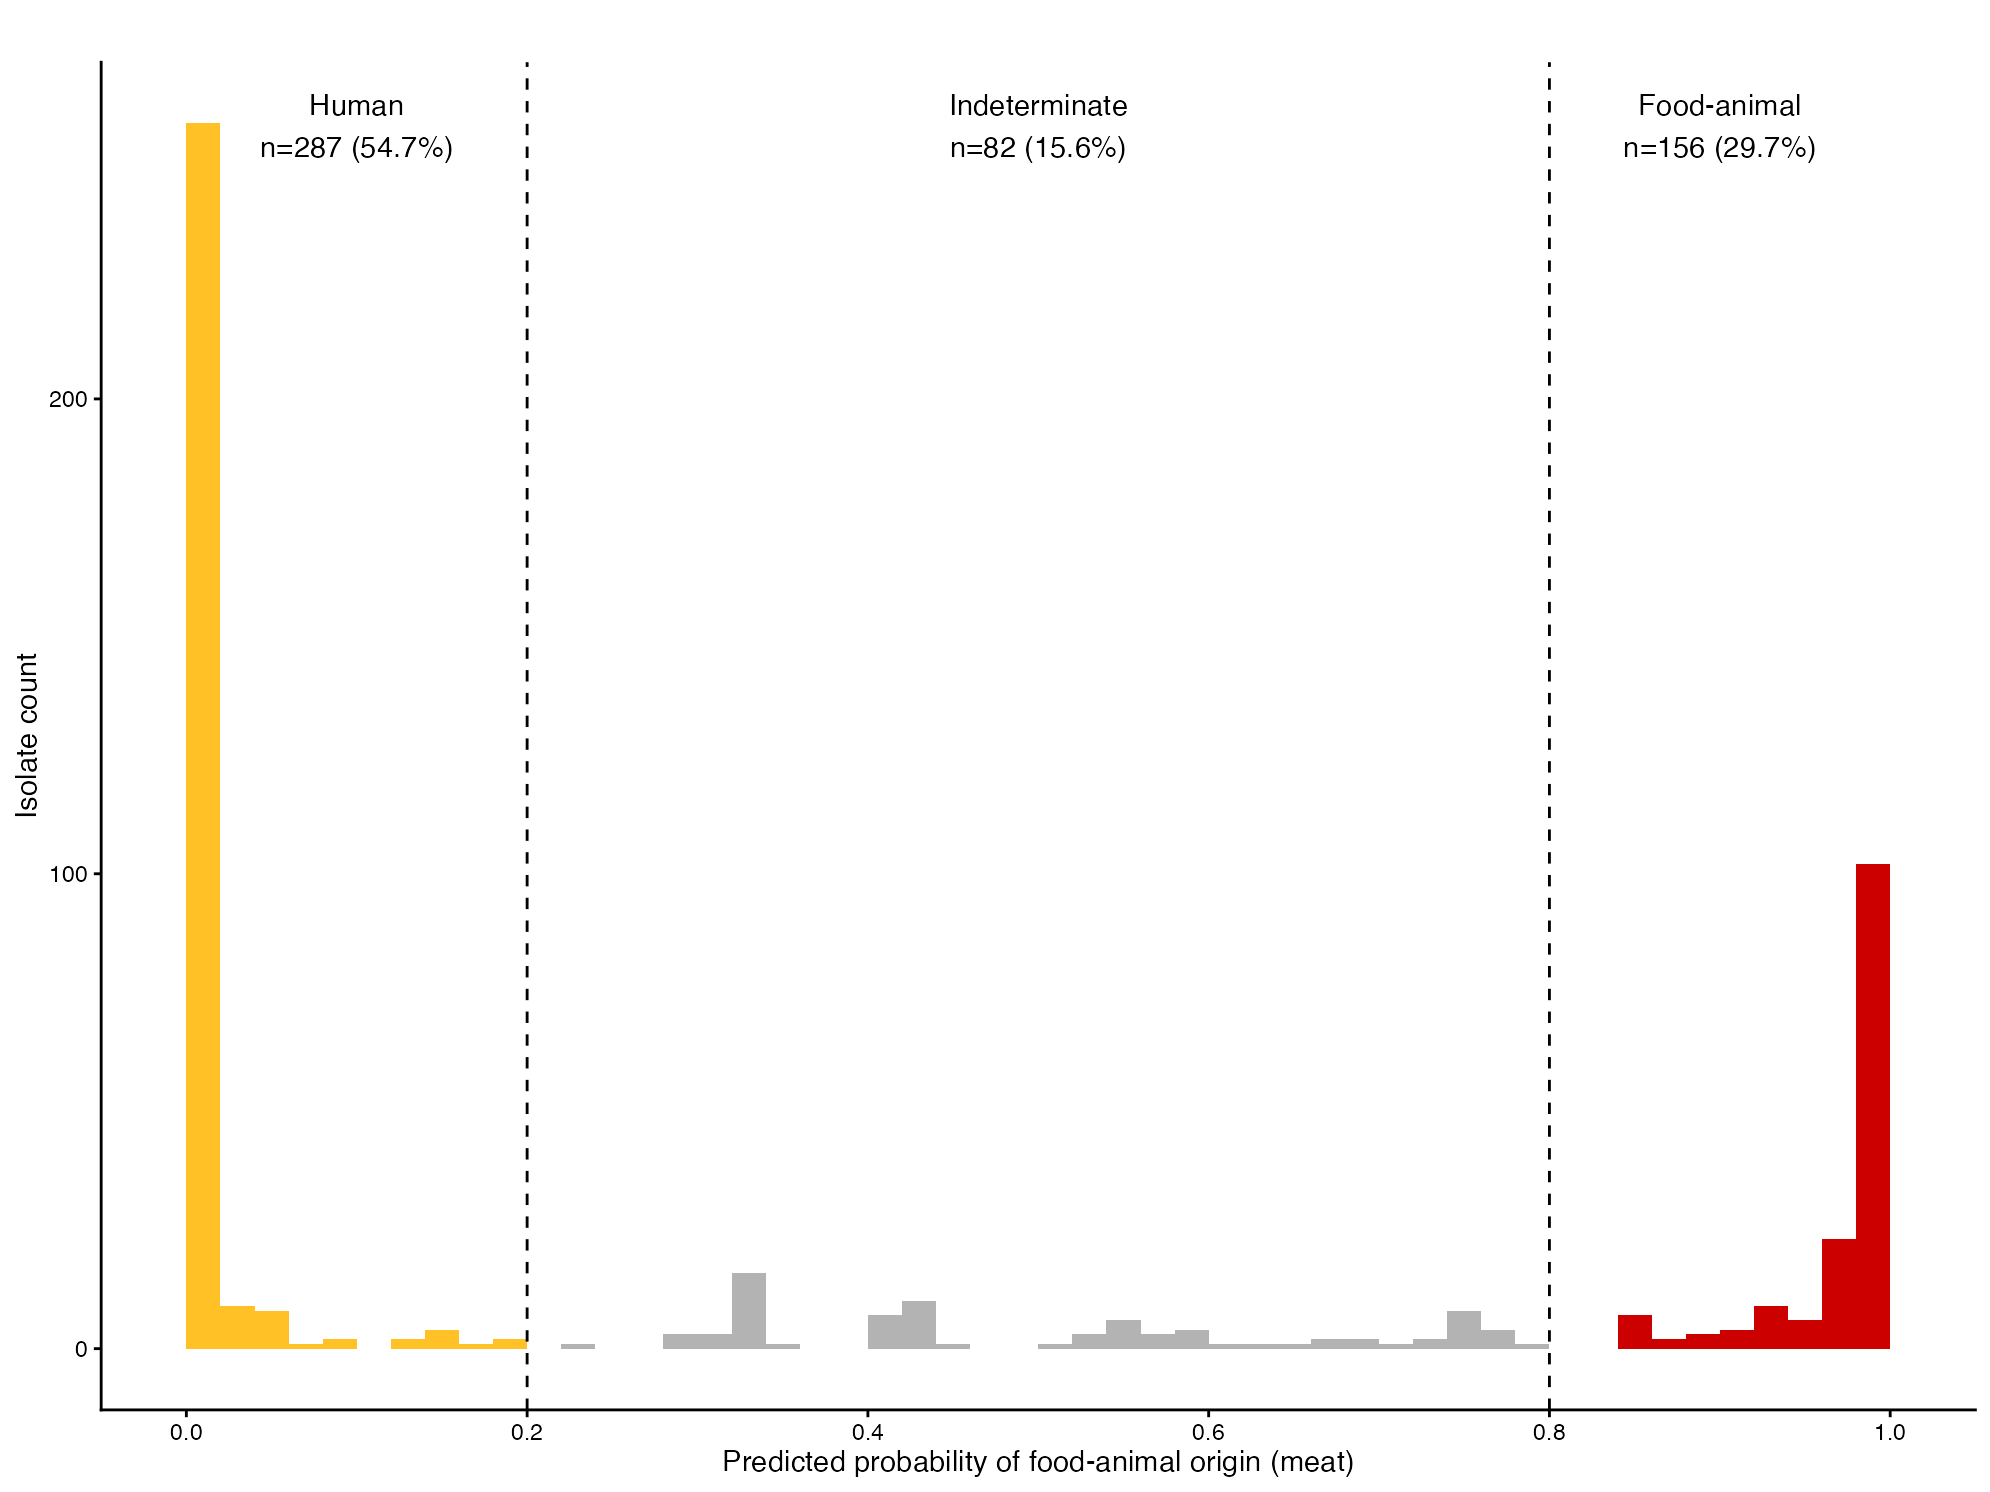

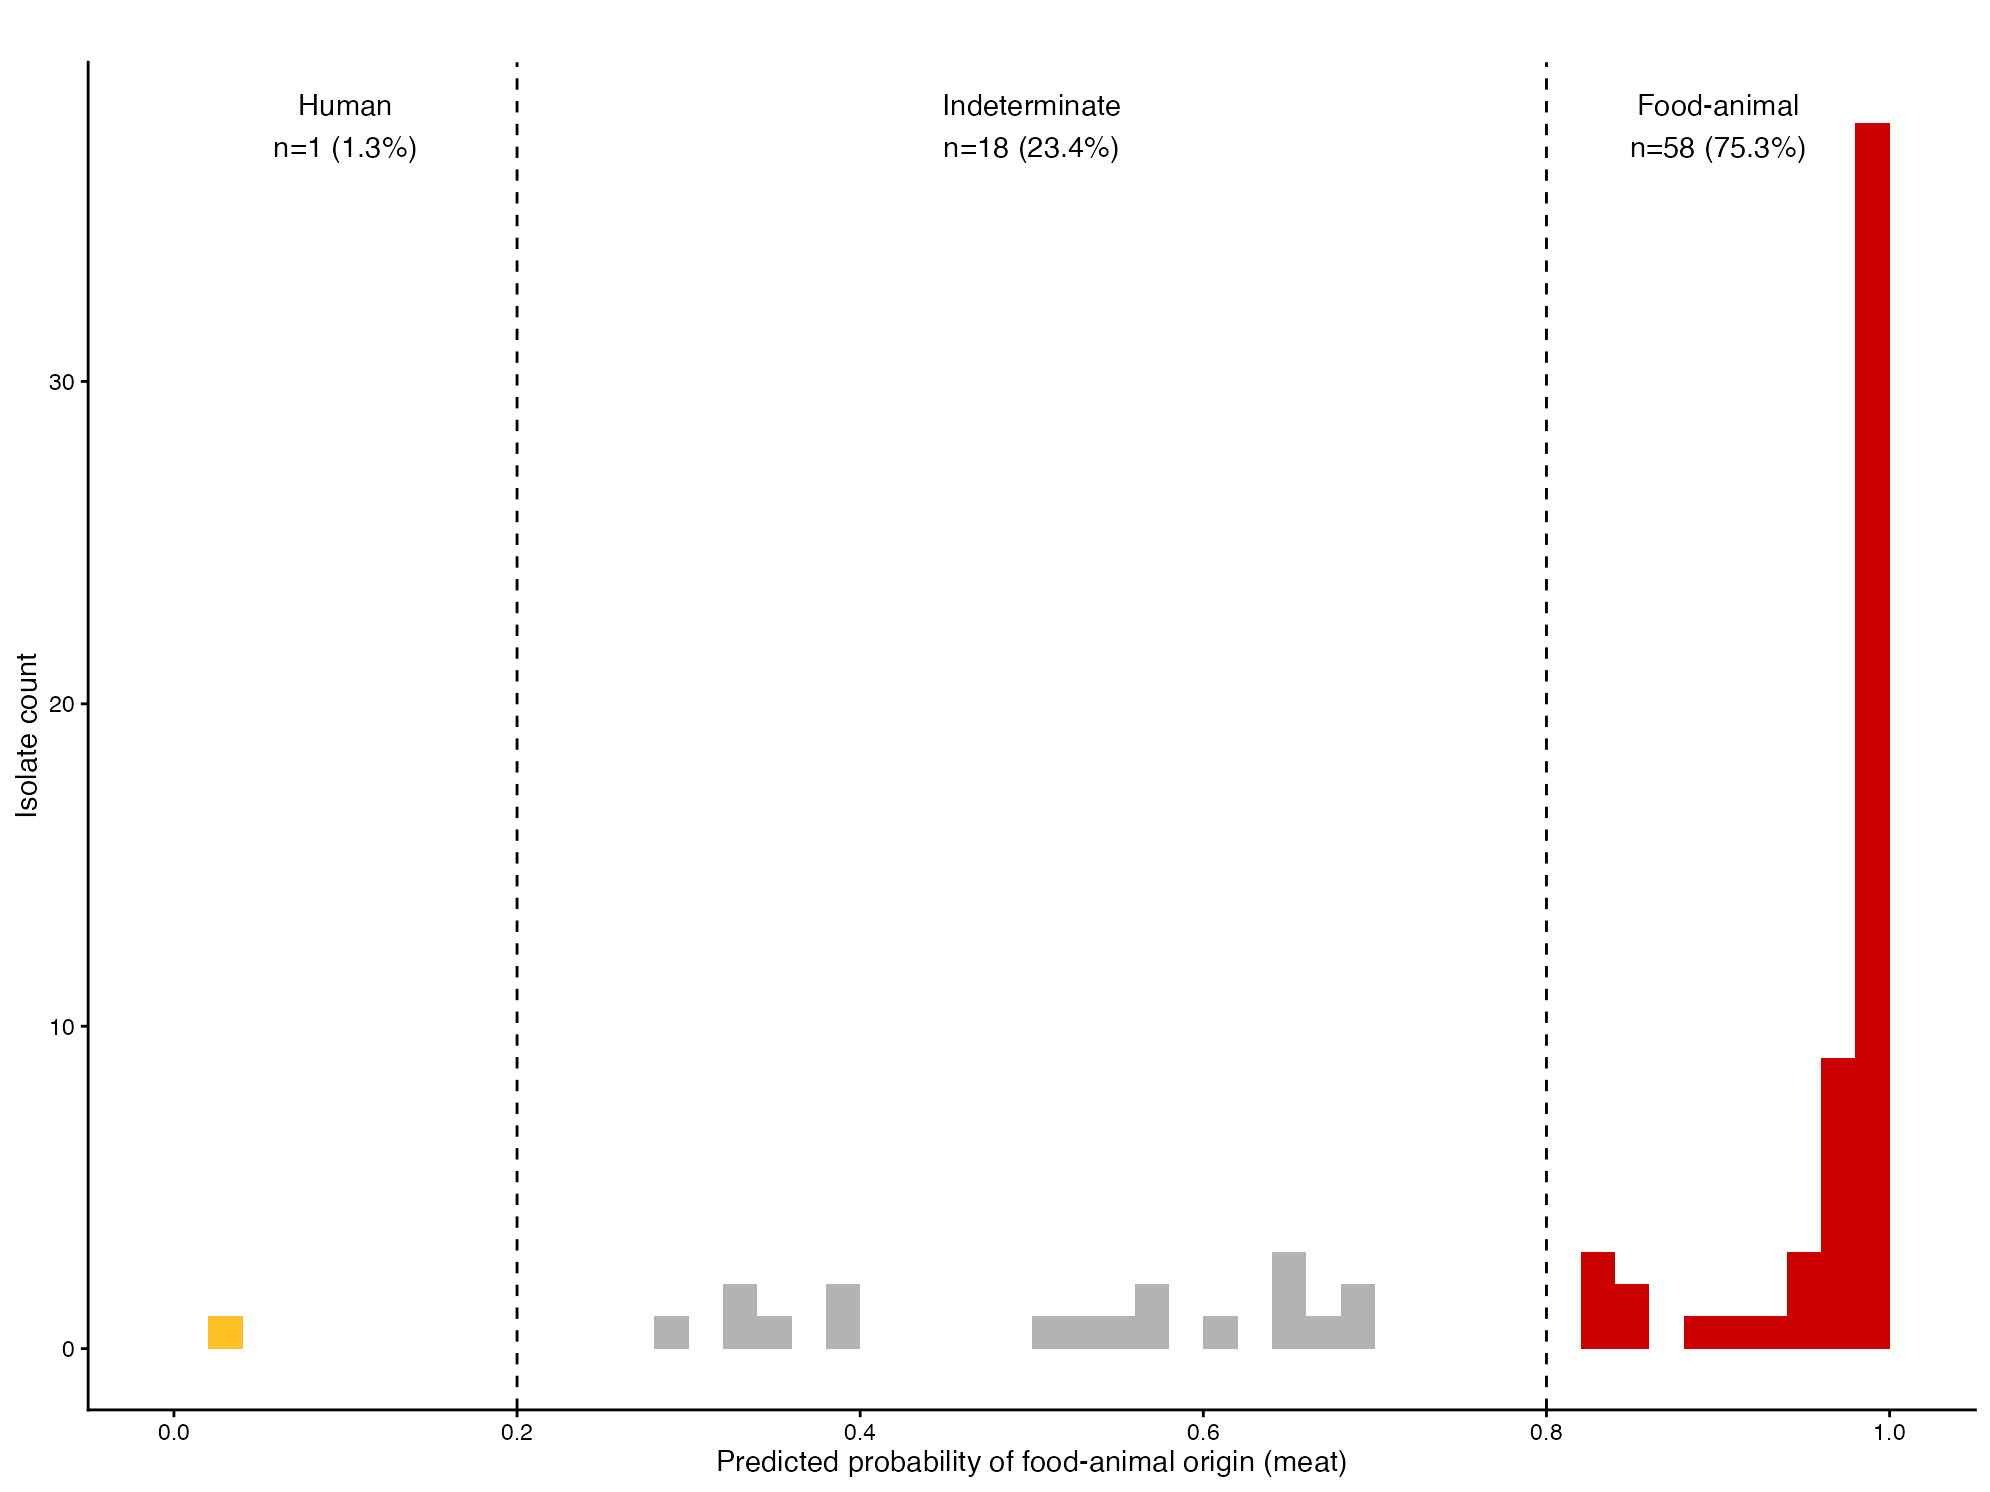

In [42]:
TAIWAN_hist_HUMAN <- generate_hist(TAIWAN_combined_HUMAN)
TAIWAN_hist_MEAT <- generate_hist(TAIWAN_combined_MEAT)
TAIWAN_hist_HUMAN
TAIWAN_hist_MEAT



## Generating treemaps

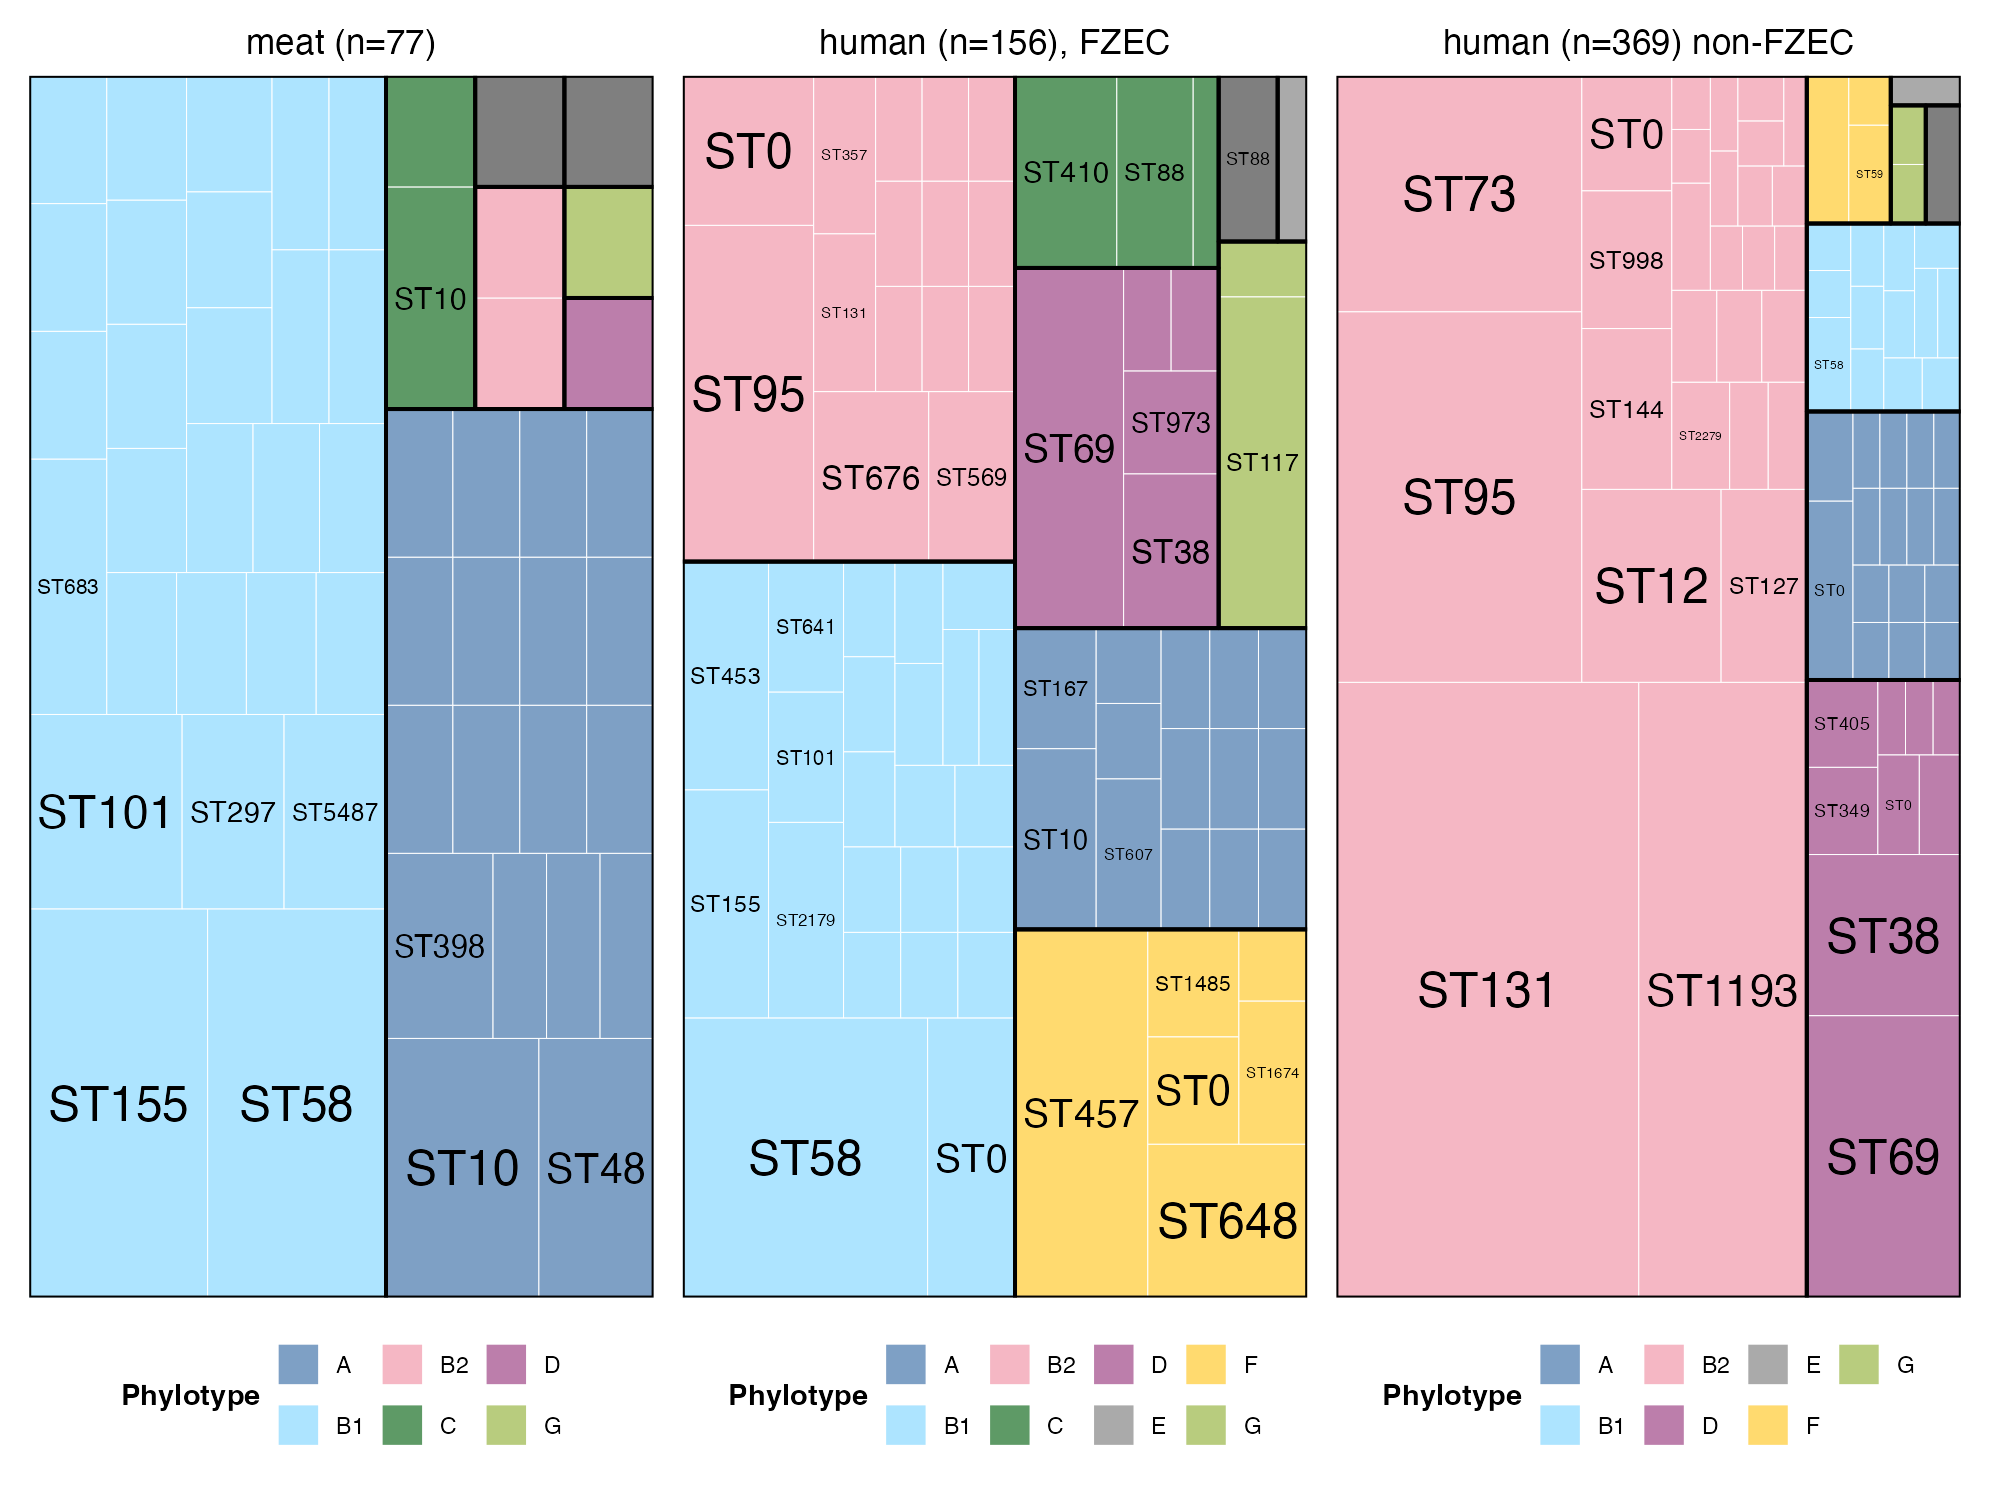

In [47]:
TAIWAN_treemap_MEAT <- generate_treemap(TAIWAN_combined_MEAT, title = "meat (n=77)")
TAIWAN_treemap_HUMAN_nonfzec <- generate_treemap(TAIWAN_combined_HUMAN, is_FZEC = 0, title = "human (n=369) non-FZEC")
TAIWAN_treemap_HUMAN_fzec <- generate_treemap(TAIWAN_combined_HUMAN, is_FZEC = 1, title = "human (n=156), FZEC")



TAIWAN_treemap_MEAT + TAIWAN_treemap_HUMAN_fzec + TAIWAN_treemap_HUMAN_nonfzec

## ST distributions

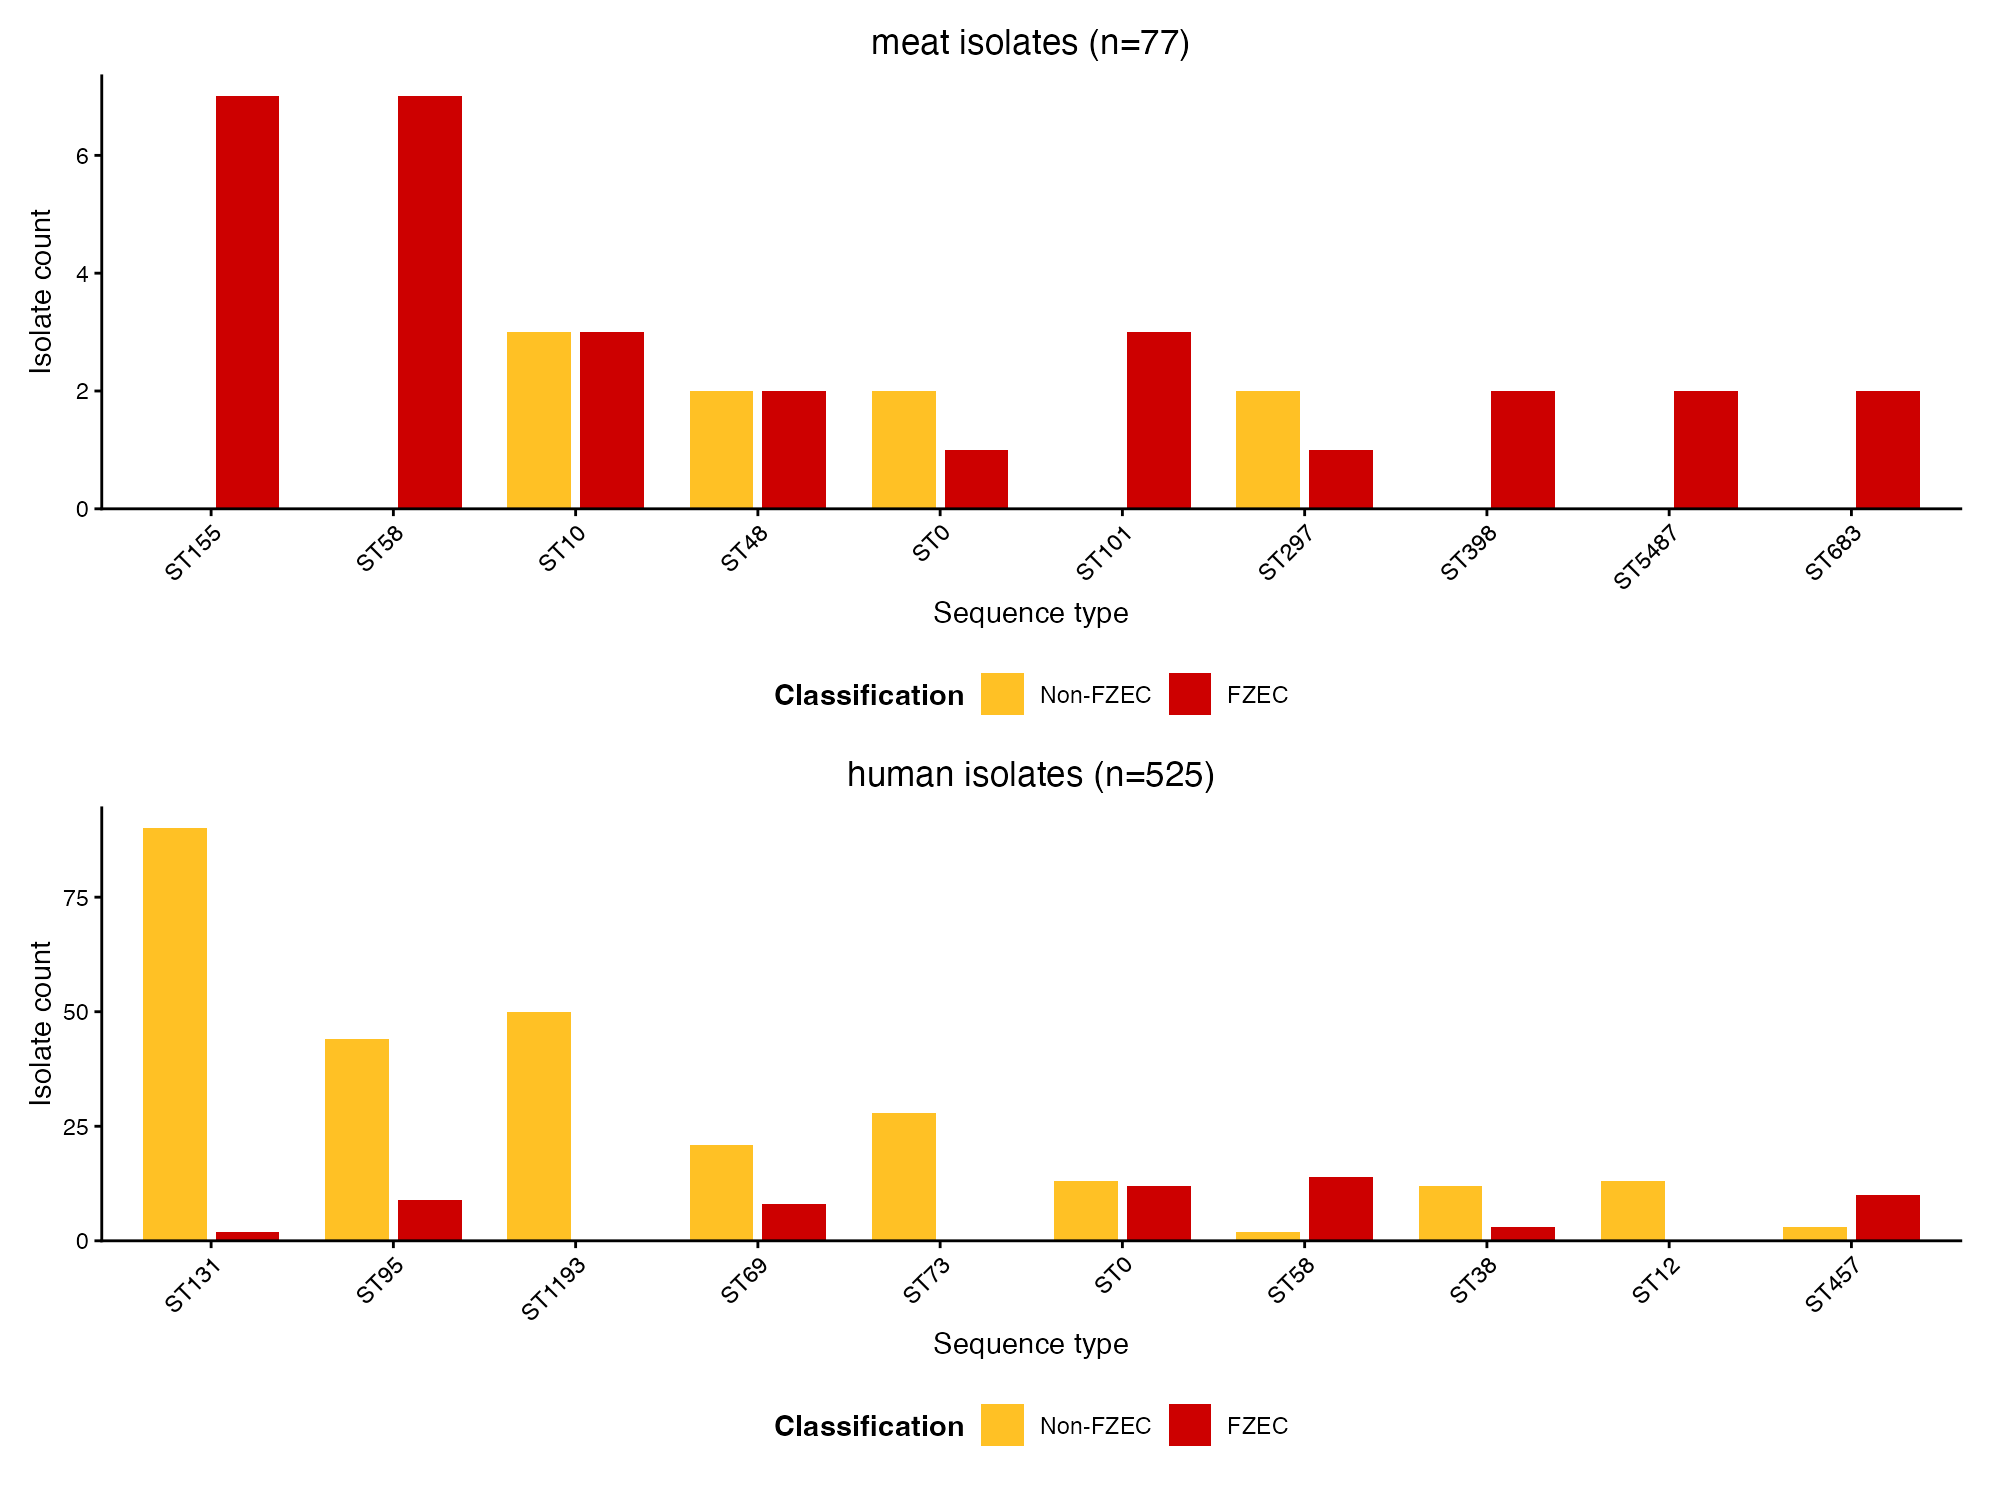

In [ ]:
TAIWAN_STdist_histogram_MEAT <- generate_ST_dist(TAIWAN_combined_MEAT, top_n = 10, title = "meat isolates (n=77)")
TAIWAN_STdist_histogram_FZEC <- generate_ST_dist(TAIWAN_combined_HUMAN, top_n = 10, title = "human isolates (n=525)")


TAIWAN_STdist_histogram_MEAT / TAIWAN_STdist_histogram_FZEC